---
title: "客户分群案例"
author: "KaisMemo"
date: "2026-03-14"
categories: [data analysis, e-commerce, customer segmentation, RFM]
---

**数据来源**：[2010-2011 年间英国某在线零售商的所有真实交易](https://www.kaggle.com/datasets/carrie1/ecommerce-data/data)

其中包含一家英国在线零售商在 2010 年 12 月 1 日至 2011 年 12 月 9 日期间发生的所有交易。该公司主要销售全场合礼品，且许多客户都是批发商。

# 数据准备

引入需要的库。

In [35]:
from datetime import timedelta

from plotly.io import renderers
from scipy import stats

import chardet as cd
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plot
import plotly.express as px
import numpy as np

推断数据编码。

In [36]:
# detect the encoding
with open('./dataset/data.csv', 'rb') as raw_data:
    encoding_detected = cd.detect(raw_data.read(20000))
print(encoding_detected)

{'encoding': 'Windows-1252', 'confidence': 1.0, 'language': 'en'}


读取数据。最好此时就把可能是 ID 的列指定为 `str` 类型，不然后续处理会比较麻烦，提前处理是一个性价比比较高的实践。

In [37]:
# read the dataset
data_origin = pd.read_csv('./dataset/data.csv', encoding=encoding_detected['encoding'], dtype={'CustomerID': str,'InvoiceNo': str})
display(data_origin)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France


数据集包含约 54 万行记录，8 列或者说 8 个维度。

下一步需要初步处理重复值、缺失值和数据类型的问题。为后续的数据探索和特征工程等做准备。

## 处理重复值

当前业务场景下，不太可能会出现内容完全一致的记录，所以重复的记录可以认为是非法记录，需要删除。

In [38]:
# handle the duplicated values
count_duplicated = data_origin.duplicated().sum()
data_origin.drop_duplicates(inplace=True)
print(f'{count_duplicated} duplicated entries been dropped.')

5268 duplicated entries been dropped.


## 处理缺失值

检查各个维度的缺失率。

In [39]:
# handle the null value
count_null = data_origin.isna().sum()
pd.DataFrame({
    'null(n)': count_null,
    'null(%)': round(((count_null / data_origin.count()) * 100), 1)
}).T

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
null(n),0.0,0.0,1454.0,0.0,0.0,0.0,135037.0,0.0
null(%),0.0,0.0,0.3,0.0,0.0,0.0,33.6,0.0


从语义上讲，`CustomerID` 无法以任何方式进行推断填充。所以把此列为空的行直接删除。

In [40]:
# drop the rows with null CustomerID
count_null_customer_id = count_null['CustomerID']
data_origin.dropna(subset=['CustomerID'], inplace=True)
print(f'{count_null_customer_id} entries with null CustomerID been dropped.')

count_null = data_origin.isna().sum()
pd.DataFrame({
    'null(n)': count_null,
    'null(%)': round(((count_null / data_origin.count()) * 100), 1)
}).T

135037 entries with null CustomerID been dropped.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
null(n),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
null(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


现在所有维度都是非空的。

## 处理数据类型

检查各个维度的数据类型。

In [41]:
# check dtypes
data_origin.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID         str
Country            str
dtype: object

`InvoiceDate` 应该是日期。

In [42]:
data_origin['InvoiceDate'] = pd.to_datetime(data_origin['InvoiceDate'])
data_origin.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

初步数据清洗结束。现在还剩约 40 万条记录。

In [43]:
display(data_origin)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


# 探索数据内容

这一步的目的是理解数据集的各个维度的语义和内容，根据语义进一步剔除非法记录，并初步洞察数据集。

## 业务语义探索

数据集有 8 个维度。根据列名初步推测业务语义：

1. `InvoiceNo`：发票号。分配给每笔交易的唯一编码。
2. `StockCode`：产品（商品）代码。分配给每种产品的唯一编码。
3. `Description`：产品（条目）名称。
4. `Quantity`：每次交易每种产品（商品）的数量。
5. `InvoiceDate`：每笔交易生成的日期和时间。
6. `UnitPrice`：单价。每单位产品价格（以英镑为单位）。
7. `CustomerID`：客户编号。分配给每个客户的 5 位唯一整数编码。
8. `Country`：国家名称。每个客户居住的国家/地区的名称。

### `InvoiceNo`

现阶段可以假设 `InvoiceNo` 是一个 6 位流水号，每个流水号代表一笔订单。

In [44]:
# check if InvoiceNO a fixed 6 width number
value_counts_invoice_no_len = data_origin['InvoiceNo'].str.len().value_counts()

pd.DataFrame({
    'n': value_counts_invoice_no_len,
    '%': round((value_counts_invoice_no_len / len(data_origin) * 100), 1)
}).T

InvoiceNo,6,7
n,392732.0,8872.0
%,97.8,2.2


假设失败，`InvoiceNo` 是 6 位或者 7 位。

In [45]:
value_counts_invoice_no_isnumeric = data_origin['InvoiceNo'].str.isnumeric().value_counts()

pd.DataFrame({
    'n': value_counts_invoice_no_isnumeric,
    '%': round((value_counts_invoice_no_isnumeric / len(data_origin) * 100), 1)
}).T

InvoiceNo,True,False
n,392732.0,8872.0
%,97.8,2.2


且 `InvoiceNo` 也并不全由数字组成。

In [46]:
mask_7_len_invoice_no = data_origin['InvoiceNo'].str.len() == 7
mask_numeric_invoice_no = data_origin['InvoiceNo'].str.isnumeric()
(mask_7_len_invoice_no != ~mask_numeric_invoice_no).sum()

np.int64(0)

经验证。所有 7 位 `InvoiceNo` 的记录与不是纯数字的 `InvoiceNo` 的记录一致。

浏览这些 7 位 `InvoiceNo` 记录。

In [47]:
data_origin[mask_7_len_invoice_no]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [48]:
data_origin[mask_7_len_invoice_no]['InvoiceNo'].str[0].value_counts()

InvoiceNo
C    8872
Name: count, dtype: int64

所有 7 位 `InvoiceNo` 的前缀都是 “C”。

In [49]:
(data_origin[mask_7_len_invoice_no]['Quantity'] < 0).sum()

np.int64(8872)

所有 7 位 `InvoiceNo` 的 `Quantity` 都小于 0。

可以推测，所有以 “C” 开头的 7 位 `InvoiceNo` 代表的记录，都表示这个订单已经被取消，所以用负值 `Quantity` 来冲抵。

如果是这样，那么这部分被取消的记录一定有对应的正向销售记录。

In [50]:
# check if ‘C’ means ‘Cancel’
data_test_cancel = data_origin[['StockCode', 'Quantity', 'InvoiceDate', 'CustomerID']]
data_test_cancel.sort_values(by=['CustomerID', 'StockCode', 'InvoiceDate'])
data_test_cancel['StockCumSum'] = data_test_cancel.groupby(['CustomerID', 'StockCode'])['Quantity'].cumsum()

def verify_row(row):
    if row['Quantity'] >= 0:
        return 'Normal Sale'
    elif row['StockCumSum'] >= 0:
        return 'Valid Return'
    else:
        return 'Orphan/Excess Return'

data_test_cancel['ValidationStatus'] = data_test_cancel.apply(verify_row, axis='columns')
count_status = data_test_cancel['ValidationStatus'].value_counts()
pd.DataFrame({
    'n': count_status,
    '%': round(((count_status / len(data_test_cancel)) * 100), 1)
}).T

ValidationStatus,Normal Sale,Valid Return,Orphan/Excess Return
n,392732.0,7462.0,1410.0
%,97.8,1.9,0.4


8872 条记录中，有 7462 条正常取消的记录，还有 1410 条没有正向销售记录，可能是由于对应的正向销售记录在数据集更往前的时间。

考虑到没有正向销售记录的仅占 0.4%，不再继续深究，直接把这部分记录删除。

In [51]:
# drop orphan orders
mask_orphan_orders = data_test_cancel['ValidationStatus'] == 'Orphan/Excess Return'
orphan_orders = data_origin[mask_orphan_orders]
data_origin.drop(index=orphan_orders.index, inplace=True)
print(f'{len(orphan_orders)} orphan entries been dropped.')

1410 orphan entries been dropped.


综上，`InvoiceNo` 整体上是一个 6 位数字流水号，但是当它以 “C” 开头，变成 7 位时，代表这条交易记录已经被取消。

### `StockCode`

现阶段可以假设 `StockCode` 是一个 5 位产品（商品）代码，但是以字母结尾，变成 6 位时，代表了某种语义。

In [52]:
value_counts_stock_code_len = data_origin['StockCode'].str.len().value_counts()

pd.DataFrame({
    'n': value_counts_stock_code_len,
    '%': round((value_counts_stock_code_len / len(data_origin) * 100), 3)
}).T

StockCode,5,6,4,1,7,2,3,12
n,365177.00,33097.00,1143.000,320.00,295.000,134.000,16.000,12.000
%,91.25,8.27,0.286,0.08,0.074,0.033,0.004,0.003


假设失败，`StockCode` 有 1~7 位和 12 位。但是绝大部分是 5 位。

In [53]:
data_origin[data_origin['StockCode'].str.len() == 5]['StockCode'].str.isnumeric().sum()

np.int64(365177)

所有 5 位 `StockCode` 都是纯数字编码。

In [54]:
data_origin[data_origin['StockCode'].str.startswith('15044')][['StockCode', 'Description']].drop_duplicates()

,StockCode,Description
1097,15044B,BLUE PAPER PARASOL
12970,15044C,PURPLE PAPER PARASOL
40154,15044A,PINK PAPER PARASOL
59815,15044D,RED PAPER PARASOL


任意抽了一个 6 位编码，看起来不同字母后缀的 `StockCode` 代表了同一产品的不同款式。

In [55]:
data_origin[data_origin['StockCode'].str.len().between(1, 4)][['StockCode', 'Description']].value_counts()

StockCode  Description               
POST       POSTAGE                       1139
M          Manual                         320
C2         CARRIAGE                       134
DOT        DOTCOM POSTAGE                  16
PADS       PADS TO MATCH ALL CUSHIONS       4
Name: count, dtype: int64

1 ~ 4 位 `StockCode` 分别表示：

- `POST`，表示邮费
- `PADS`，表示包装用的垫子费用
- `DOT`，表示在线邮费
- `C2`，表示运费
- `M`，表示手动录入的特殊费用

> 客户在前端网站下单购买时，运费用 DOT，经销商大宗运输时，运费用 C2，小批量补发商品时，用 POST

In [56]:
data_origin[data_origin['StockCode'].str.len() == 12]['StockCode'].value_counts()

StockCode
BANK CHARGES    12
Name: count, dtype: int64

所有 12 位 `StockCode` 都是 `BANK CHARGES`，表示银行收取的交易费用。

综上，`StockCode` 有多种形式：

- 5 位数字（+ 1 位字母）编码，表示一款产品
- `D`、`M`、`C2`、`DOT`、`PADS`、`POST`、`BANK CHARGES` 分别代表附带的特殊费用或折扣

### 其他维度

按照语义来讲，预期 `Quantity` 和 `UnitPrice` 应该呈现右偏分布。

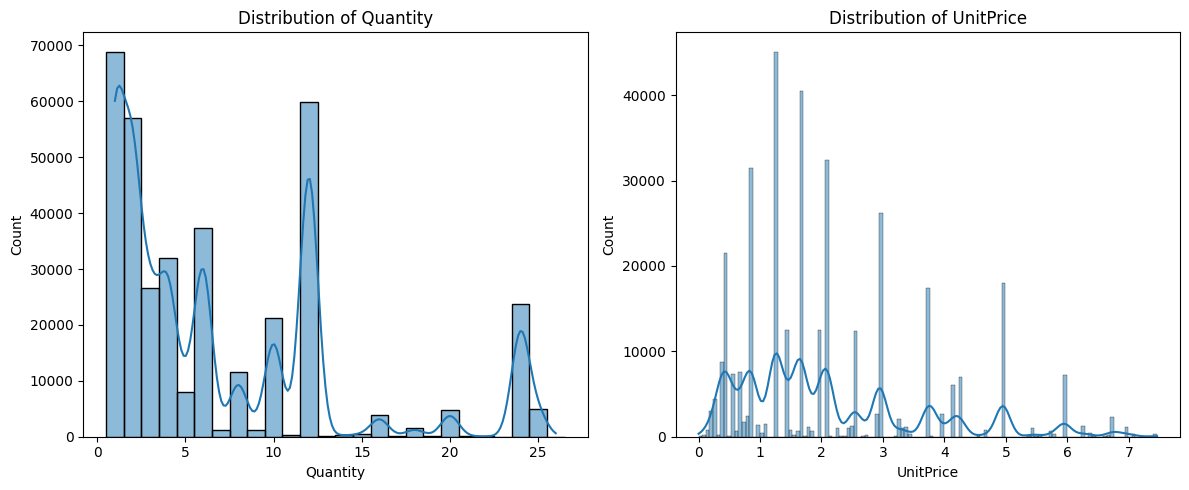

In [57]:
fig, axis = plot.subplots(nrows=1, ncols=2, figsize=(12, 5))

mask_product_sale = (data_origin['Quantity'] > 0) & data_origin['StockCode'].str.len().between(5,6)
data_product_sale = data_origin[mask_product_sale]

q1_of_quantity = data_product_sale['Quantity'].quantile(0.25)
q3_of_quantity = data_product_sale['Quantity'].quantile(0.75)
iqr_of_quantity = q3_of_quantity - q1_of_quantity
mask_no_outlier_quantity = data_product_sale['Quantity'] < q3_of_quantity + 1.5 * iqr_of_quantity

q1_of_unit_price = data_product_sale['UnitPrice'].quantile(0.25)
q3_of_unit_price = data_product_sale['UnitPrice'].quantile(0.75)
iqr_of_unit_price = q3_of_unit_price - q1_of_unit_price
mask_no_outlier_unit_price = data_product_sale['UnitPrice'] < q3_of_unit_price + 1.5 * iqr_of_unit_price

hist_quantity = sb.histplot(data_product_sale[mask_no_outlier_quantity]['Quantity'], ax=axis[0], bins='fd', kde=True, discrete=True)
hist_unit_price = sb.histplot(data_product_sale[mask_no_outlier_unit_price]['UnitPrice'], ax=axis[1], bins='fd', kde=True)

hist_quantity.set_title('Distribution of Quantity')
hist_unit_price.set_title('Distribution of UnitPrice')

plot.tight_layout()
plot.show()

从图上看，大体符合预期。

In [58]:
data_origin['CustomerID'].str.len().value_counts()

CustomerID
5    400194
Name: count, dtype: int64

In [59]:
data_origin['CustomerID'].str.isnumeric().value_counts()

CustomerID
True    400194
Name: count, dtype: int64

`CustomerID` 是一个 5 位数字。

In [60]:
data_origin['Country'].value_counts()

Country
United Kingdom          355446
Germany                   9422
France                    8462
EIRE                      7453
Spain                     2524
Netherlands               2369
Belgium                   2068
Switzerland               1877
Portugal                  1468
Australia                 1255
Norway                    1083
Italy                      797
Channel Islands            756
Finland                    695
Cyprus                     610
Sweden                     460
Austria                    400
Denmark                    389
Japan                      355
Poland                     341
USA                        291
Israel                     245
Unspecified                241
Singapore                  227
Iceland                    182
Canada                     151
Greece                     146
Malta                      126
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon                     45


`Country` 看起来没有 Typo 问题。

In [71]:
value_counts_country = data_origin['Country'].value_counts().reset_index()
value_counts_country.columns = ['Country', 'Count']

fig = px.choropleth(value_counts_country,
                    locations='Country',
                    locationmode='country names',
                    color='Count',
                    hover_name='Country',
                    title='Distribution of Country')

fig.show(renderers='html')

C:\Users\z1197\AppData\Local\Temp\ipykernel_15016\2136694786.py:4: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



可以发现，英国的订单量远高于其他地区。考虑到数据集来自于英国商店，有其合理性。

## 分离退货订单和销售订单

现在的订单汇中，混杂了取消订单和销售订单。此处有两条处理思路：

- 考虑把退货订单匹配回原始销售订单，增加一个维度用于表示已经取消的商品数量，用于后续计算订单的真实价值
- 直接分离退货订单和销售订单，分开分析

此处我倾向于选择后者，因为退货订单可能无法精确匹配到原始订单，即使匹配，也可能存在部分退货、多次退货等复杂情况，分离分析避免了匹配错误带来的偏差。再者，购买行为代表客户的购买意愿和消费能力，退货行为代表客户满意度、产品质量问题、物流问题等，两者分开分析：可以更清晰地看到客户的真实行为模式。

In [62]:
mask_canceled = data_origin['InvoiceNo'].str.startswith('C')
data_canceled = data_origin[mask_canceled]
data = data_origin[~mask_canceled]
data_product_sale = data[data['InvoiceNo'].str.len().between(5, 6)]

# 特征工程

这一步的目的是把原始数据转换成便于进行 RFM 分群的样子。

In [63]:
data_product_sale['TotalAmount'] = data_product_sale['Quantity'] * data_product_sale['UnitPrice']
base_date = data_product_sale['InvoiceDate'].max() + timedelta(days=1)
data_rfm = data_product_sale.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (base_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()
data_rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# 探索性数据分析

我将从三个维度展开 EDA：

- 单变量分析：检查 R、F、M 各自的分布特征
- 双变量分析：探索 R-F、R-M、F-M 之间的相关性
- 多变量分析：识别异常客户群体

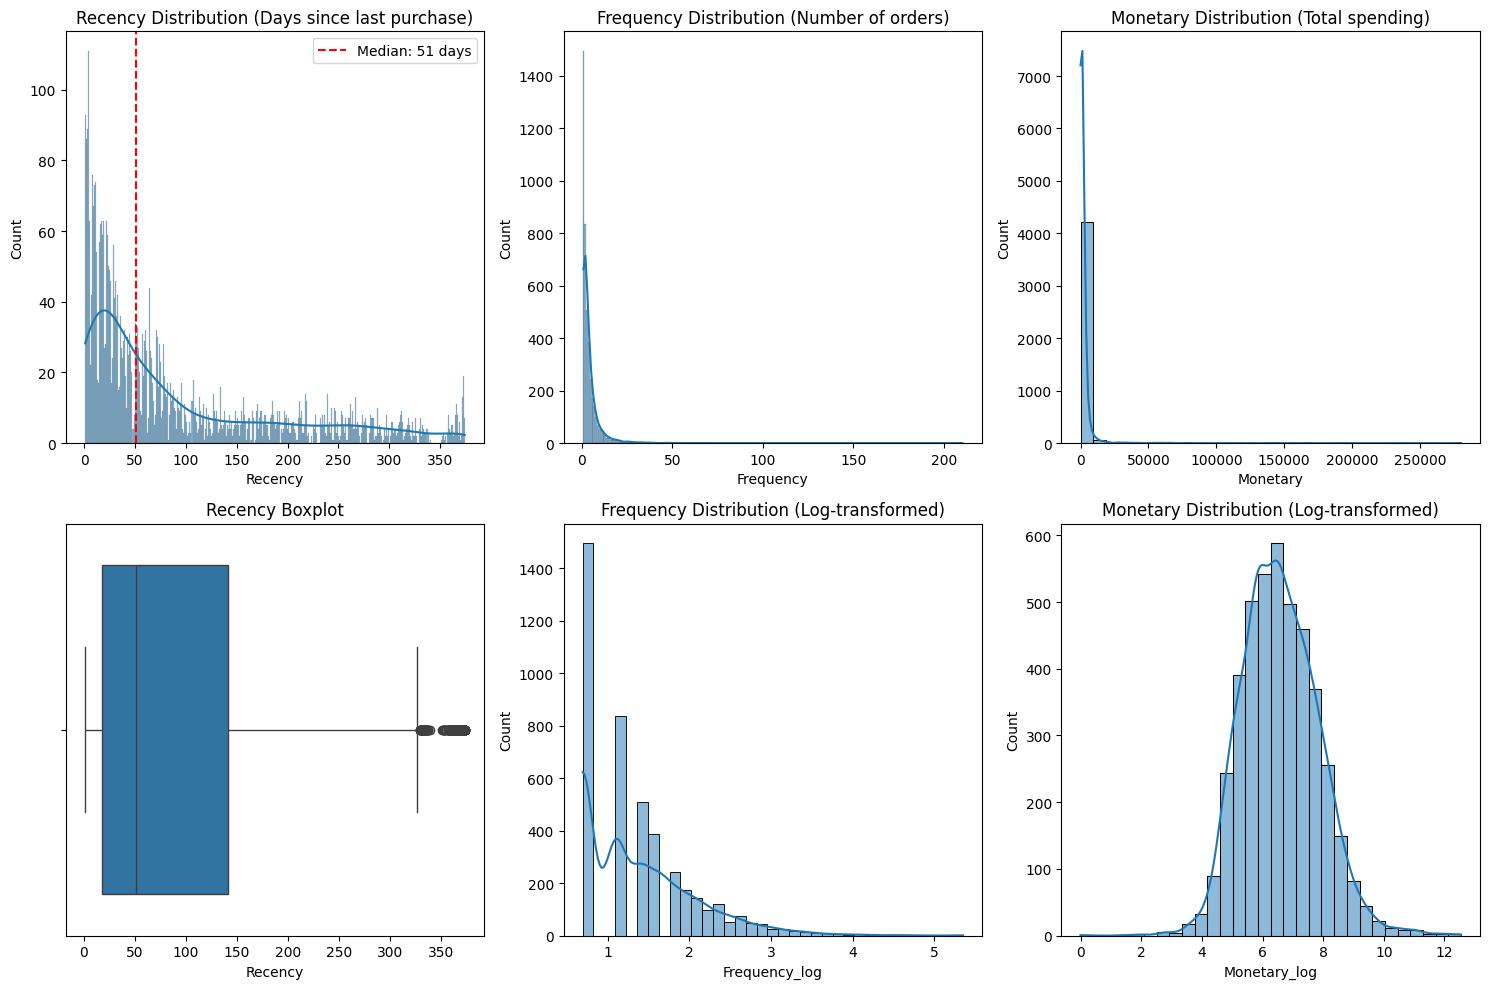

In [64]:
# single variable analysis
fig, axis = plot.subplots(2, 3, figsize=(15, 10))

# Recency
sb.histplot(data=data_rfm, x='Recency', discrete=True, kde=True, ax=axis[0, 0])
axis[0, 0].set_title('Recency Distribution (Days since last purchase)')
axis[0, 0].axvline(data_rfm['Recency'].median(), color='red', linestyle='--',
                   label=f'Median: {data_rfm["Recency"].median():.0f} days')
axis[0, 0].legend()
sb.boxplot(data=data_rfm, x='Recency', ax=axis[1, 0])
axis[1, 0].set_title('Recency Boxplot')

# Frequency
sb.histplot(data=data_rfm, x='Frequency', discrete=True, kde=True, ax=axis[0, 1])
axis[0, 1].set_title('Frequency Distribution (Number of orders)')
# Frequency usually has a long tail
data_rfm['Frequency_log'] = np.log1p(data_rfm['Frequency'])
sb.histplot(data=data_rfm, x='Frequency_log', bins='fd', kde=True, ax=axis[1, 1])
axis[1, 1].set_title('Frequency Distribution (Log-transformed)')

# Monetary
sb.histplot(data=data_rfm, x='Monetary', bins=30, kde=True, ax=axis[0, 2])
axis[0, 2].set_title('Monetary Distribution (Total spending)')
# Monetary usually has a long tail
data_rfm['Monetary_log'] = np.log1p(data_rfm['Monetary'])
sb.histplot(data=data_rfm, x='Monetary_log', bins=30, kde=True, ax=axis[1, 2])
axis[1, 2].set_title('Monetary Distribution (Log-transformed)')

plot.tight_layout()
plot.show()

Recency，呈现右偏分布（大多数客户近期购买过），如果分布均匀或左偏，可能表示客户流失；Frequency 呈现幂律分布，少数客户频繁购买，多数客户购买次数少，Monetary，呈现极度右偏，表示少数 VIP 客户贡献大部分收入。

In [65]:
# describe statistic
rfm_stats = data_rfm[['Recency', 'Frequency', 'Monetary']].describe()
rfm_stats.loc['skewness'] = data_rfm[['Recency', 'Frequency', 'Monetary']].apply(stats.skew)
rfm_stats.loc['kurtosis'] = data_rfm[['Recency', 'Frequency', 'Monetary']].apply(stats.kurtosis)
print("RFM Descriptive Statistics with Skewness and Kurtosis:")
rfm_stats

RFM Descriptive Statistics with Skewness and Kurtosis:


,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2048.215924
std,100.009747,7.705493,8984.248352
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,306.455000
50%,51.000000,2.000000,668.560000
75%,142.000000,5.000000,1660.315000
max,374.000000,210.000000,280206.020000
skewness,1.245926,12.095844,19.334716
kurtosis,0.429503,250.082433,478.234792


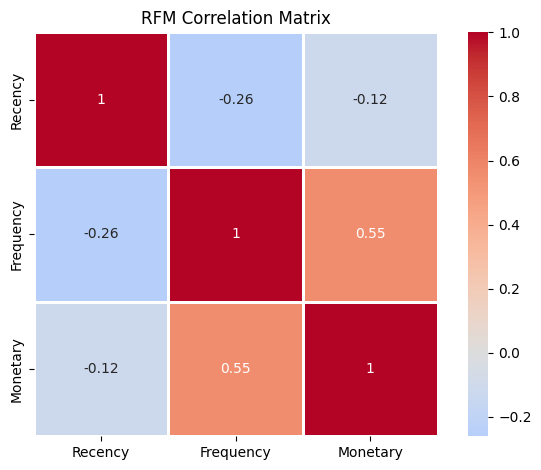

In [66]:
# correlation matrix
correlation_matrix = data_rfm[['Recency', 'Frequency', 'Monetary']].corr()
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plot.title('RFM Correlation Matrix')

plot.tight_layout()
plot.show()

R 与 F 负相关（最近购买客户通常更活跃），F 与 M 正相关（购买次数多则总消费高），R 与 M 关系复杂，无明显相关性。

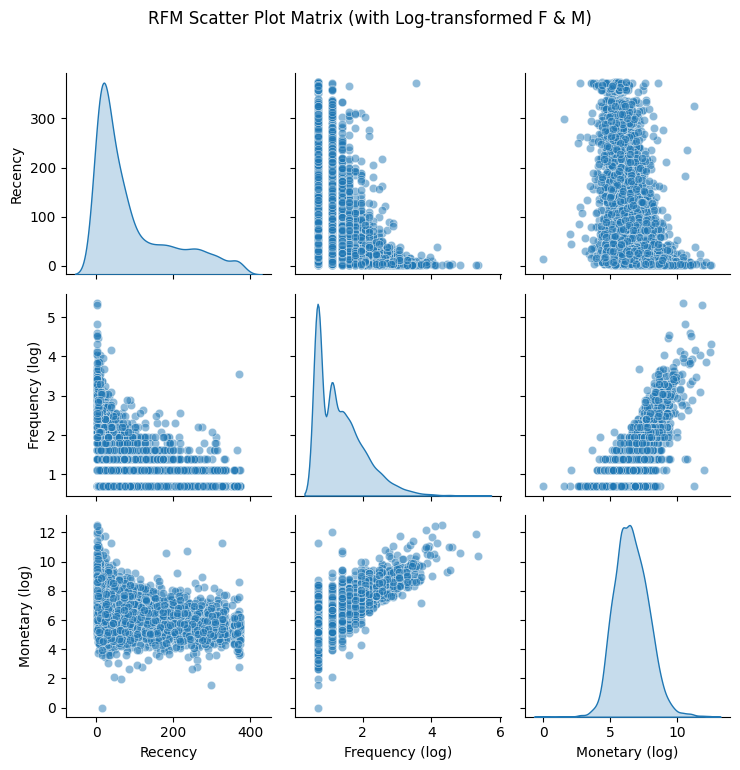

In [67]:
data_rfm_log = data_rfm[['Recency', 'Frequency_log', 'Monetary_log']].copy()
data_rfm_log.columns = ['Recency', 'Frequency (log)', 'Monetary (log)']
sb.pairplot(data_rfm_log, diag_kind='kde', plot_kws={'alpha': 0.5})
plot.suptitle('RFM Scatter Plot Matrix (with Log-transformed F & M)', y=1.02)

plot.tight_layout()
plot.show()